Base Features Model: RDKit Descriptors + Morgan Fingerprints
=============================================================================
This notebook trains Random Forest classifiers on RDKit 2D descriptors + Morgan fingerprints
(no pre-reaction metadata), evaluates test-set performance, and compares 1024 vs 2048-bit models.

# 1. Imports & Settings

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import shap
import pingouin as pg

from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, AllChem

from model_comparison import make_boxplots_parametric, make_mcs_plot_grid, make_ci_plot_grid, make_normality_diagnostic

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import clone
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    make_scorer, accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
from sklearn.metrics import average_precision_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from IPython.display import display
from scipy.stats import shapiro, levene
import statsmodels.api as sm


# Comparative analysis imports
from scipy.special import ndtr
from scipy.stats import ttest_rel, wilcoxon, norm

# Seeds and bootstrap settings
SEEDS = [37, 42, 53, 69]
N_BOOT = 1000

c:\Users\hllpacke\.conda\envs\epimerisation\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. Load & Preprocess Data

In [2]:
# Adjust path to your CSV
DATA_PATH = "M:/EPSRC Internship 2025/Project/Data/Classification Model/epimerisation_data_clean.csv"
df = pd.read_csv(DATA_PATH, usecols=['epimerisation','smilesstarting_material']) 
# Rename SMILES column for convenience
df.rename(columns={'smilesstarting_material':'SMILES'}, inplace=True)
y = df['epimerisation'].astype(int).values

# 2.1 Compute RDKit Descriptors

In [3]:
# Compute RDKit descriptors
def compute_rdkit_descriptors(smiles, prefix):
    names = [f"{prefix}_{n}" for n,_ in Descriptors._descList]
    vals = []
    for smi in smiles:
        m = Chem.MolFromSmiles(smi)
        vals.append([f(m) if m else np.nan for _,f in Descriptors._descList])
    return pd.DataFrame(vals, columns=names)

rdkit_df = compute_rdkit_descriptors(df['SMILES'], 'rdkit')

# Compute Morgan fingerprints + density
def compute_morgan(smiles, radius=2, n_bits=1024, prefix='morgan'):
    fps, dens = [], []
    for smi in smiles:
        m = Chem.MolFromSmiles(smi)
        if m:
            fp = AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits=n_bits)
            arr = np.zeros((n_bits,), dtype=int)
            DataStructs.ConvertToNumpyArray(fp, arr)
            fps.append(arr)
            dens.append(arr.sum()/n_bits)
        else:
            fps.append(np.full((n_bits,), np.nan))
            dens.append(np.nan)
    cols = [f"{prefix}_bit_{i}" for i in range(n_bits)]
    df_bits = pd.DataFrame(fps, columns=cols)
    df_bits[f"{prefix}_density"] = dens
    return df_bits

morgan_df = compute_morgan(df['SMILES'], radius=2, n_bits=1024, prefix='morgan')

# Combine & drop missing
X = pd.concat([rdkit_df, morgan_df], axis=1)
mask = X.notna().all(axis=1)
X = X[mask].reset_index(drop=True)
y = y[mask]

[15:14:39] DEPRECATION WARNING: please use MorganGenerator
[15:14:39] DEPRECATION WARNING: please use MorganGenerator
[15:14:39] DEPRECATION WARNING: please use MorganGenerator
[15:14:39] DEPRECATION WARNING: please use MorganGenerator
[15:14:39] DEPRECATION WARNING: please use MorganGenerator
[15:14:39] DEPRECATION WARNING: please use MorganGenerator
[15:14:39] DEPRECATION WARNING: please use MorganGenerator
[15:14:39] DEPRECATION WARNING: please use MorganGenerator
[15:14:39] DEPRECATION WARNING: please use MorganGenerator
[15:14:39] DEPRECATION WARNING: please use MorganGenerator
[15:14:39] DEPRECATION WARNING: please use MorganGenerator
[15:14:39] DEPRECATION WARNING: please use MorganGenerator
[15:14:39] DEPRECATION WARNING: please use MorganGenerator
[15:14:39] DEPRECATION WARNING: please use MorganGenerator
[15:14:39] DEPRECATION WARNING: please use MorganGenerator
[15:14:39] DEPRECATION WARNING: please use MorganGenerator
[15:14:39] DEPRECATION WARNING: please use MorganGenerat

# 3. Feature Builder: Morgan Fingerprints + Descriptors

In [4]:
def make_features(df, n_bits, smiles_col='smilesstarting_material'):
    """
    Return DataFrame with n_bits Morgan FPs + precomputed descriptors.
    """
    fps = []
    for smi in df[smiles_col]:
        m = Chem.MolFromSmiles(smi)
        if m:
            fp = AllChem.GetMorganFingerprintAsBitVect(m, radius=2, nBits=n_bits)
            arr = np.array(fp)
        else:
            arr = np.zeros((n_bits,), dtype=int)
        fps.append(arr)
    fp_df = pd.DataFrame(fps, columns=[f"FP_{i}" for i in range(n_bits)])
    return pd.concat([fp_df, df[DESC_NAMES].reset_index(drop=True)], axis=1)

# 4. Pipeline Assembly

In [5]:

# 1) Train/test split (80/20 stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2) Correlation filter to remove highly collinear features
class CorrFilter(BaseEstimator, TransformerMixin):
    def __init__(self, thresh=0.9, feature_names=None):
        self.thresh = thresh
        self.feature_names = feature_names
    def fit(self, X, y=None):
        C = pd.DataFrame(X, columns=self.feature_names).corr().abs()
        U = C.where(np.triu(np.ones(C.shape),k=1).astype(bool))
        drop = [c for c in U.columns if any(U[c] > self.thresh)]
        self.keep = [i for i,f in enumerate(self.feature_names) if f not in drop]
        return self
    def transform(self, X):
        return X[:, self.keep]

feat_names = X.columns.tolist()

# 3) Build pipeline with SMOTE & Random Forest + hyperparameter tuning
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pipe = ImbPipeline([
    ("imp",   SimpleImputer(strategy="mean")),
    ("scale", StandardScaler()),
    ("corr",  CorrFilter(thresh=0.9, feature_names=feat_names)),
    ("smote", SMOTE(random_state=42)),
    ("clf",   RandomForestClassifier(class_weight="balanced", random_state=42))
])
param_dist = {
    "clf__n_estimators":      [100, 200, 300],
    "clf__max_depth":         [None, 10, 20],
    "clf__min_samples_split": [2, 5, 10]
}
rs = RandomizedSearchCV(
    pipe, param_distributions=param_dist,
    n_iter=20, scoring="precision", cv=cv,
    random_state=42, n_jobs=-1
)
# fit on training portion
rs.fit(X_train, y_train)
best = rs.best_estimator_

# 4) Compute per-fold cross-validated metrics on the training set
cv_records = []
X_train_arr = X_train.values
y_train_arr = y_train
for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train_arr, y_train_arr)):
    # clone and fit pipeline on this fold
    fold_pipe = clone(best)
    X_tr_fold, y_tr_fold = X_train_arr[train_idx], y_train_arr[train_idx]
    X_val_fold, y_val_fold = X_train_arr[val_idx],   y_train_arr[val_idx]
    fold_pipe.fit(X_tr_fold, y_tr_fold)
    # predict on validation fold
    y_pred_fold  = fold_pipe.predict(X_val_fold)
    y_proba_fold = fold_pipe.predict_proba(X_val_fold)[:,1]
    # record metrics
    cv_records.append({
        'fold':    fold_idx,
        'MCC':     matthews_corrcoef   (y_val_fold, y_pred_fold),
        'ROC AUC': roc_auc_score       (y_val_fold, y_proba_fold),
        'PR AUC':  average_precision_score(y_val_fold, y_proba_fold)
    })
cv_metrics_df = pd.DataFrame(cv_records)
print("=== Cross-Validated Fold Metrics ===")
display(cv_metrics_df.round(3))

# 5) Now predict on held-out test set
y_test_pred  = best.predict(X_test)
y_test_proba = best.predict_proba(X_test)[:,1]

# 6) Compute test metrics
test_metrics = {
    "Accuracy":  accuracy_score    (y_test, y_test_pred),
    "Precision": precision_score   (y_test, y_test_pred),
    "Recall":    recall_score      (y_test, y_test_pred),
    "F1":        f1_score          (y_test, y_test_pred),
    "ROC AUC":   roc_auc_score     (y_test, y_test_proba),
    "MCC":       matthews_corrcoef(y_test, y_test_pred)
}
cm = confusion_matrix(y_test, y_test_pred)

print("\n=== TEST SET METRICS ===")
print(pd.DataFrame(test_metrics, index=["Value"]).T.round(3))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print("Confusion Matrix:\n", cm)


c:\Users\hllpacke\.conda\envs\epimerisation\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\hllpacke\.conda\envs\epimerisation\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\hllpacke\.conda\envs\epimerisation\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
c:\Users\hllpacke\.conda\

=== Cross-Validated Fold Metrics ===


,fold,MCC,ROC AUC,PR AUC
0,0,0.775,1.000,1.000
1,1,0.542,0.917,0.955
2,2,0.770,0.875,0.955
3,3,0.389,0.833,0.964
4,4,0.043,0.778,0.952



=== TEST SET METRICS ===
           Value
Accuracy   0.867
Precision  0.917
Recall     0.917
F1         0.917
ROC AUC    0.972
MCC        0.583

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.92      0.92      0.92        12

    accuracy                           0.87        15
   macro avg       0.79      0.79      0.79        15
weighted avg       0.87      0.87      0.87        15

Confusion Matrix:
 [[ 2  1]
 [ 1 11]]


In [6]:
# --- 1) Extract and label your basic‐features CV metrics ---
# Assume `cv_metrics_df` holds your per‐fold metrics for the 1024‐bit (basic) pipeline,
# and has columns ['bits','fold','MCC','ROC AUC','PR AUC'].

# Filter out only the basic‐features (1024‐bit) runs and drop the bits column:
basic_cv_df = cv_metrics_df.copy()
if "bits" in basic_cv_df.columns:
    basic_cv_df = basic_cv_df[basic_cv_df.bits == 1024].drop(columns="bits")

# Add a column to label this as the basic CV model:
basic_cv_df["model"] = "basic_cv"

# Reorder so 'model' and 'fold' come first
cols = ["model", "fold"] + [c for c in basic_cv_df.columns if c not in ("model", "fold")]
basic_cv_df = basic_cv_df[cols]

# 1a) Inspect
print("Basic CV pipeline fold‐metrics:")
display(basic_cv_df.round(3))

# --- 2) Save to pickle ---
out_file = "basic_cv_metrics.pkl"
basic_cv_df.to_pickle(out_file)
print(f"✅ Saved basic‐features CV metrics to {out_file!r}")

# --- 3) (Later, in any notebook) you can reload via: ---
# import pandas as pd
# loaded_basic_cv = pd.read_pickle("basic_cv_metrics.pkl")
# display(loaded_basic_cv)


Basic CV pipeline fold‐metrics:


,model,fold,MCC,ROC AUC,PR AUC
0,basic_cv,0,0.775,1.000,1.000
1,basic_cv,1,0.542,0.917,0.955
2,basic_cv,2,0.770,0.875,0.955
3,basic_cv,3,0.389,0.833,0.964
4,basic_cv,4,0.043,0.778,0.952


✅ Saved basic‐features CV metrics to 'basic_cv_metrics.pkl'


# 5. Y-randomisation 

In [7]:
# 10) Y-randomization with cross-validation on TRAINING set (50 shuffles)

# define a scorer for MCC
mcc_scorer = make_scorer(matthews_corrcoef)

# we'll reuse the same pipeline & cv scheme you defined above
rand_res = {m: [] for m in test_metrics}

for i in range(50):
    # shuffle the training labels
    y_shuf = np.random.permutation(y_train)
    # run cross‐validation on X_train / y_shuf
    cv_results = cross_validate(
        best,                    # your tuned pipeline from above
        X_train, 
        y_shuf,
        cv=cv,                   # same StratifiedKFold
        scoring={
            "Accuracy": "accuracy",
            "Precision": "precision",
            "Recall": "recall",
            "F1": "f1",
            "ROC AUC": "roc_auc",
            "MCC": mcc_scorer
        },
        return_train_score=False,
        n_jobs=-1
    )
    # record the mean of each fold‐score
    rand_res["Accuracy"].append(cv_results["test_Accuracy"].mean())
    rand_res["Precision"].append(cv_results["test_Precision"].mean())
    rand_res["Recall"].append(cv_results["test_Recall"].mean())
    rand_res["F1"].append(cv_results["test_F1"].mean())
    rand_res["ROC AUC"].append(cv_results["test_ROC AUC"].mean())
    rand_res["MCC"].append(cv_results["test_MCC"].mean())

# summarize
rand_summary = []
for m, vals in rand_res.items():
    arr = np.array(vals)
    mu, sd = arr.mean(), arr.std(ddof=1)
    observed = test_metrics[m]
    z = (observed - mu) / sd if sd > 0 else np.nan
    p = 1 - ndtr(z) if not np.isnan(z) else np.nan
    rand_summary.append({
        "Metric": m,
        "Real": round(observed, 3),
        "Rand Mean±SD": f"{mu:.3f}±{sd:.3f}",
        "Z-score": round(z, 3) if not np.isnan(z) else np.nan,
        "p-value": round(p, 3) if not np.isnan(p) else np.nan
    })

print("\n=== Y-RANDOMIZATION (Test) ===")
display(pd.DataFrame(rand_summary).set_index("Metric"))



=== Y-RANDOMIZATION (Test) ===


,Real,Rand Mean±SD,Z-score,p-value
Metric,,,,
Accuracy,0.867,0.661±0.055,3.711,0.000
Precision,0.917,0.769±0.036,4.109,0.000
Recall,0.917,0.797±0.057,2.110,0.017
F1,0.917,0.776±0.042,3.363,0.000
ROC AUC,0.972,0.492±0.125,3.826,0.000
MCC,0.583,0.012±0.144,3.972,0.000


# 6. Metric visualisations 

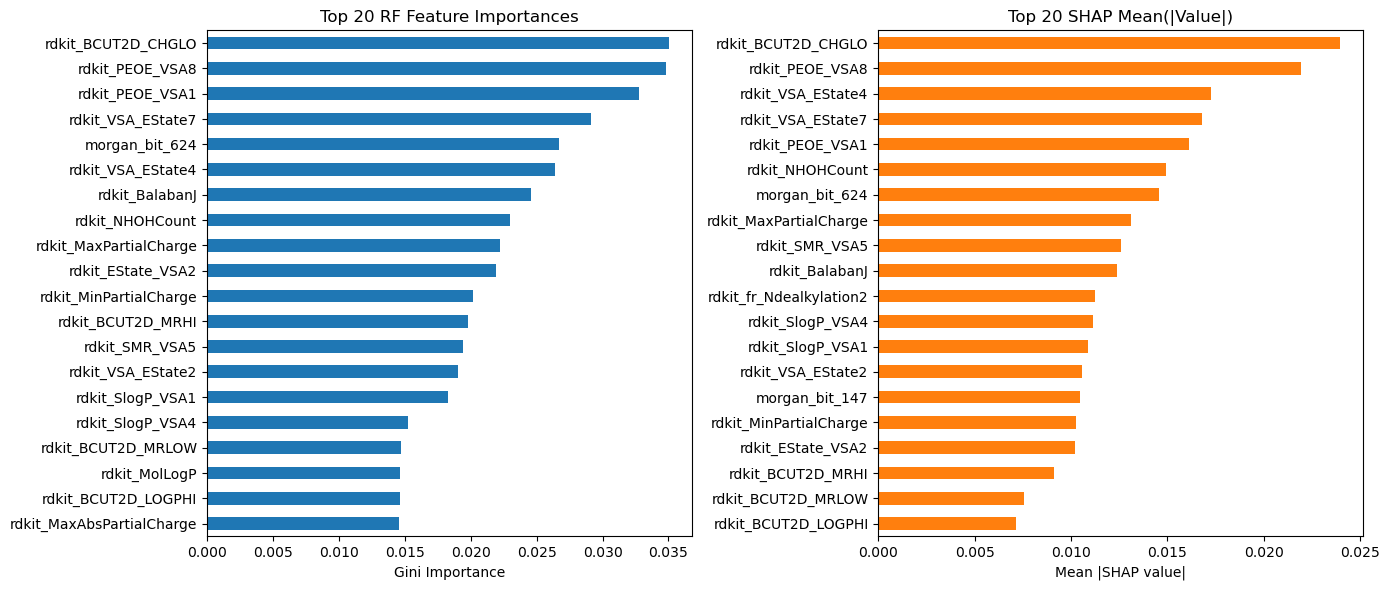

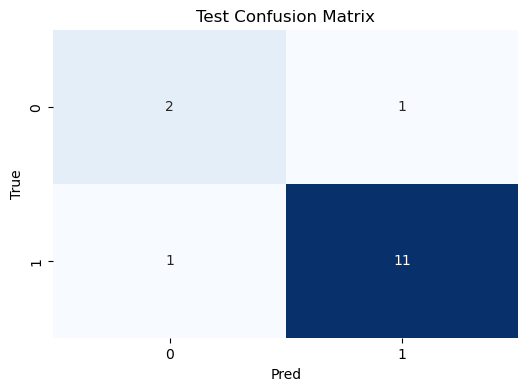

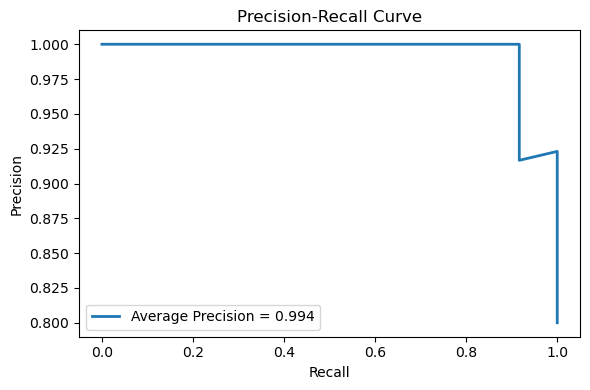

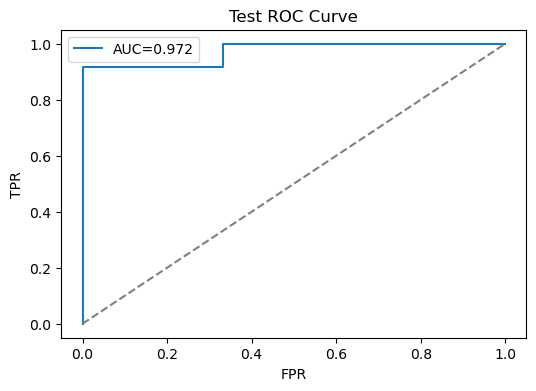

In [8]:
# RF & SHAP Feature Importances Side-by-Side 

# RF importances (post-corr filter)
keep_idx    = best.named_steps["corr"].keep
final_feats = np.array(feat_names)[keep_idx]  # Only the features kept after correlation filter
rf_imp      = best.named_steps["clf"].feature_importances_
# Ensure rf_imp and final_feats have the same length
assert len(rf_imp) == len(final_feats), f"rf_imp ({len(rf_imp)}) and final_feats ({len(final_feats)}) length mismatch"
rf_series   = pd.Series(rf_imp, index=final_feats).sort_values(ascending=False)

# SHAP importances
#  a) Transform TEST set through the pipeline up to the classifier
X_imp = best.named_steps["imp"].transform(X_test)
X_sc  = best.named_steps["scale"].transform(X_imp)
X_cf  = best.named_steps["corr"].transform(X_sc)

#  b) Compute SHAP values
explainer = shap.TreeExplainer(best.named_steps["clf"])
shap_vals = explainer.shap_values(X_cf)

#  c) Extract the “positive‐class” SHAP array in a robust way
# For binary classification, shap_vals is a list of 2 arrays (n_samples, n_features)
if isinstance(shap_vals, list):
    arr = shap_vals[1]  # positive class
else:
    arr = shap_vals

# Ensure arr shape matches (n_samples, n_features)
if arr.shape[1] != len(final_feats):
    raise ValueError(f"SHAP values shape {arr.shape} does not match number of features {len(final_feats)}")

#  d) Mean(|SHAP|) across samples
# If shap_imp is 2D (n_features, 2), reduce to 1D by averaging over the last axis
shap_imp = np.abs(arr).mean(axis=0)
if shap_imp.ndim == 2:
    shap_imp = shap_imp.mean(axis=1)
shap_series = pd.Series(shap_imp, index=final_feats).sort_values(ascending=False)

# Plot them side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rf_series.head(20).plot(
    kind="barh", ax=axes[0], color="C0"
)
axes[0].invert_yaxis()
axes[0].set_title("Top 20 RF Feature Importances")
axes[0].set_xlabel("Gini Importance")

shap_series.head(20).plot(
    kind="barh", ax=axes[1], color="C1"
)
axes[1].invert_yaxis()
axes[1].set_title("Top 20 SHAP Mean(|Value|)")
axes[1].set_xlabel("Mean |SHAP value|")

plt.tight_layout()
plt.show()


# Confusion matrix & ROC curve
import seaborn as sns

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Test Confusion Matrix"); plt.xlabel("Pred"); plt.ylabel("True")
plt.show()

prec, rec, _ = precision_recall_curve(y_test, y_test_proba)
ap = average_precision_score(y_test, y_test_proba)

plt.figure(figsize=(6,4))
plt.plot(rec, prec, lw=2, label=f"Average Precision = {ap:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC={test_metrics['ROC AUC']:.3f}")
plt.plot([0,1],[0,1],'--',c='gray')
plt.title("Test ROC Curve"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend()
plt.show()

# 1024 vs 2048 Morgan Fingerprint Bit Models

In [9]:
data= pd.read_csv(r"M:\EPSRC Internship 2025\Project\Data\Classification Model\Comparisons\Polaris\cv_metrics_1024_2048.csv")

In [10]:
data = data.drop(columns=["Unnamed: 0.2", "Unnamed: 0"])

# 7. Homogeneity of Variances Assumption

In [11]:
metric_ls= ['mcc', 'roc_auc', 'pr_auc']
for metric in metric_ls:
    groups = data.groupby('method')[metric].apply(list)
    stat, pvalue = levene(*groups)
    print(f'Levene test for {metric}: p-value = {pvalue}')



Levene test for mcc: p-value = 1.0
Levene test for roc_auc: p-value = 0.7668395649422862
Levene test for pr_auc: p-value = 0.7297229556679712


In [12]:
variances_by_method = data.groupby('method')[metric_ls].var()
max_fold_diff = variances_by_method.max() / variances_by_method.min()
print(max_fold_diff)

mcc        1.000000
roc_auc    1.325301
pr_auc     1.375749
dtype: float64


# 8. Normality Assumption

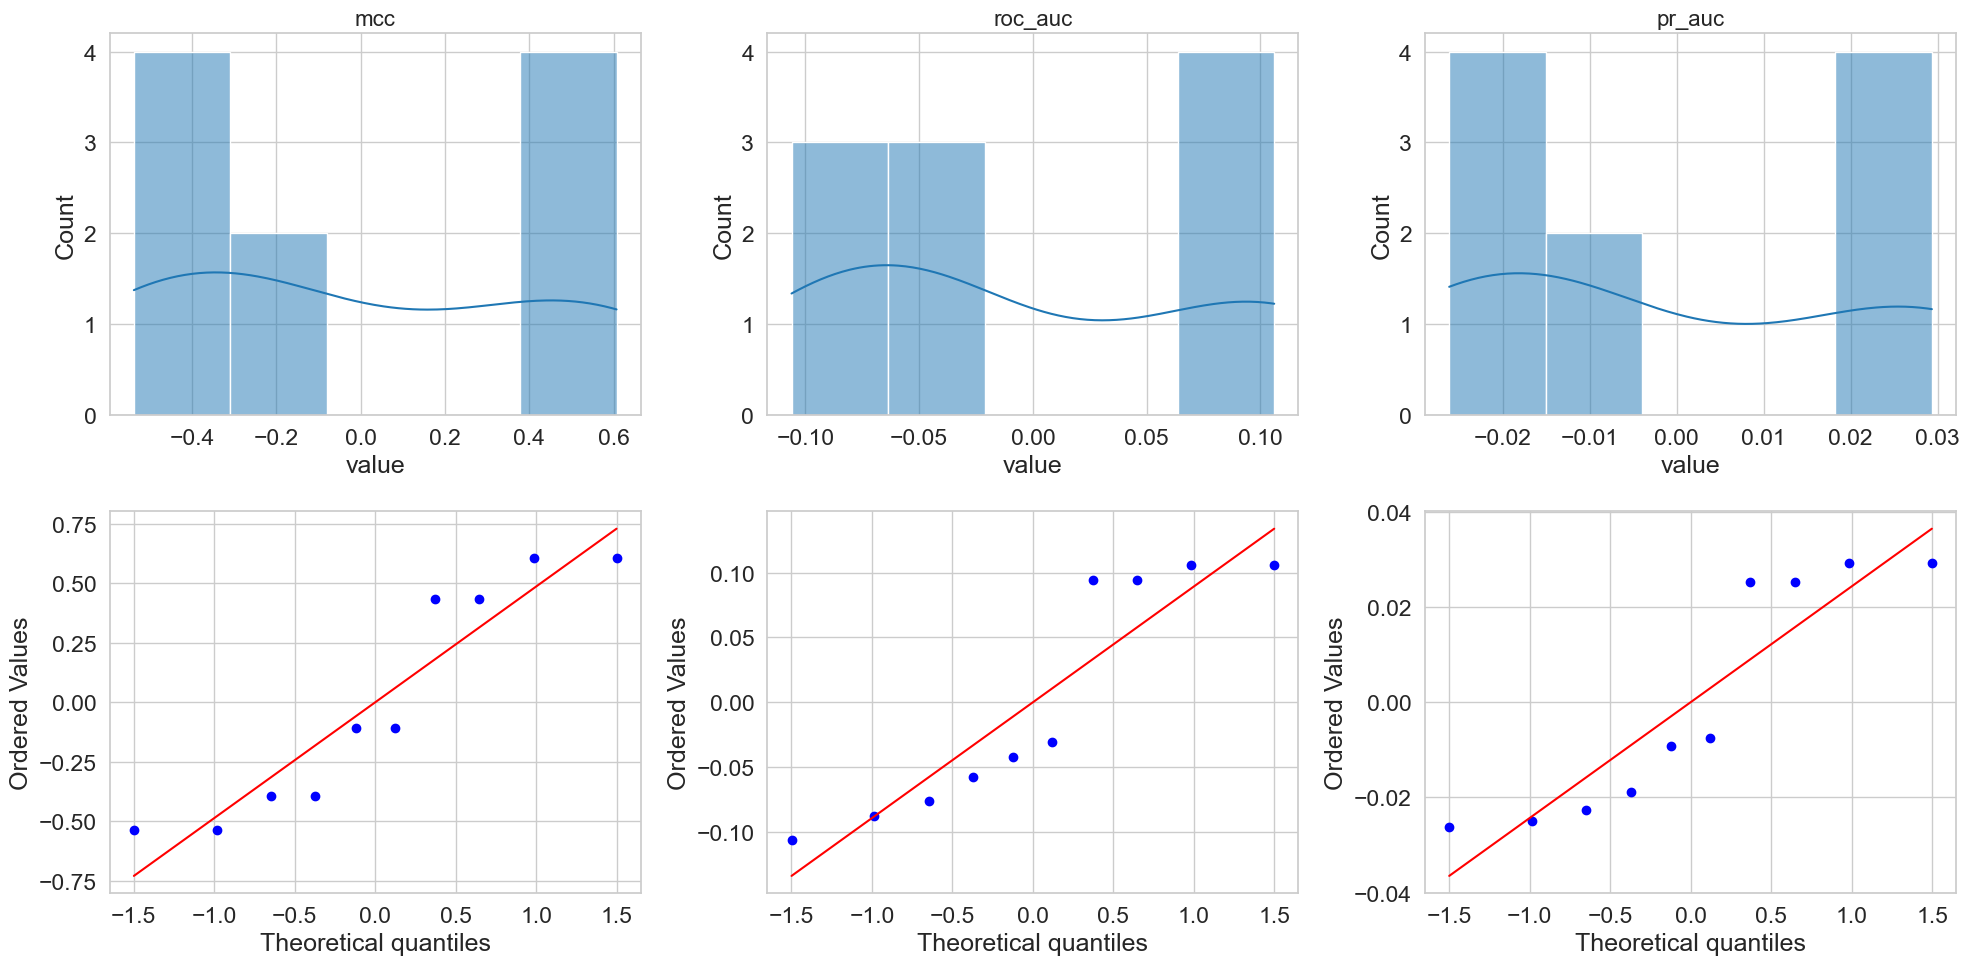

In [13]:
make_normality_diagnostic(data, metric_ls)

# 9. Perform Repeated Measures ANOVA

Aggregated DataFrame columns: ['cv_cycle', 'method', 'mcc', 'roc_auc', 'pr_auc']
Rows per cv_cycle×method:
cv_cycle  method
1         b1024     1
          b2048     1
2         b1024     1
          b2048     1
3         b1024     1
          b2048     1
4         b1024     1
          b2048     1
5         b1024     1
          b2048     1
dtype: int64


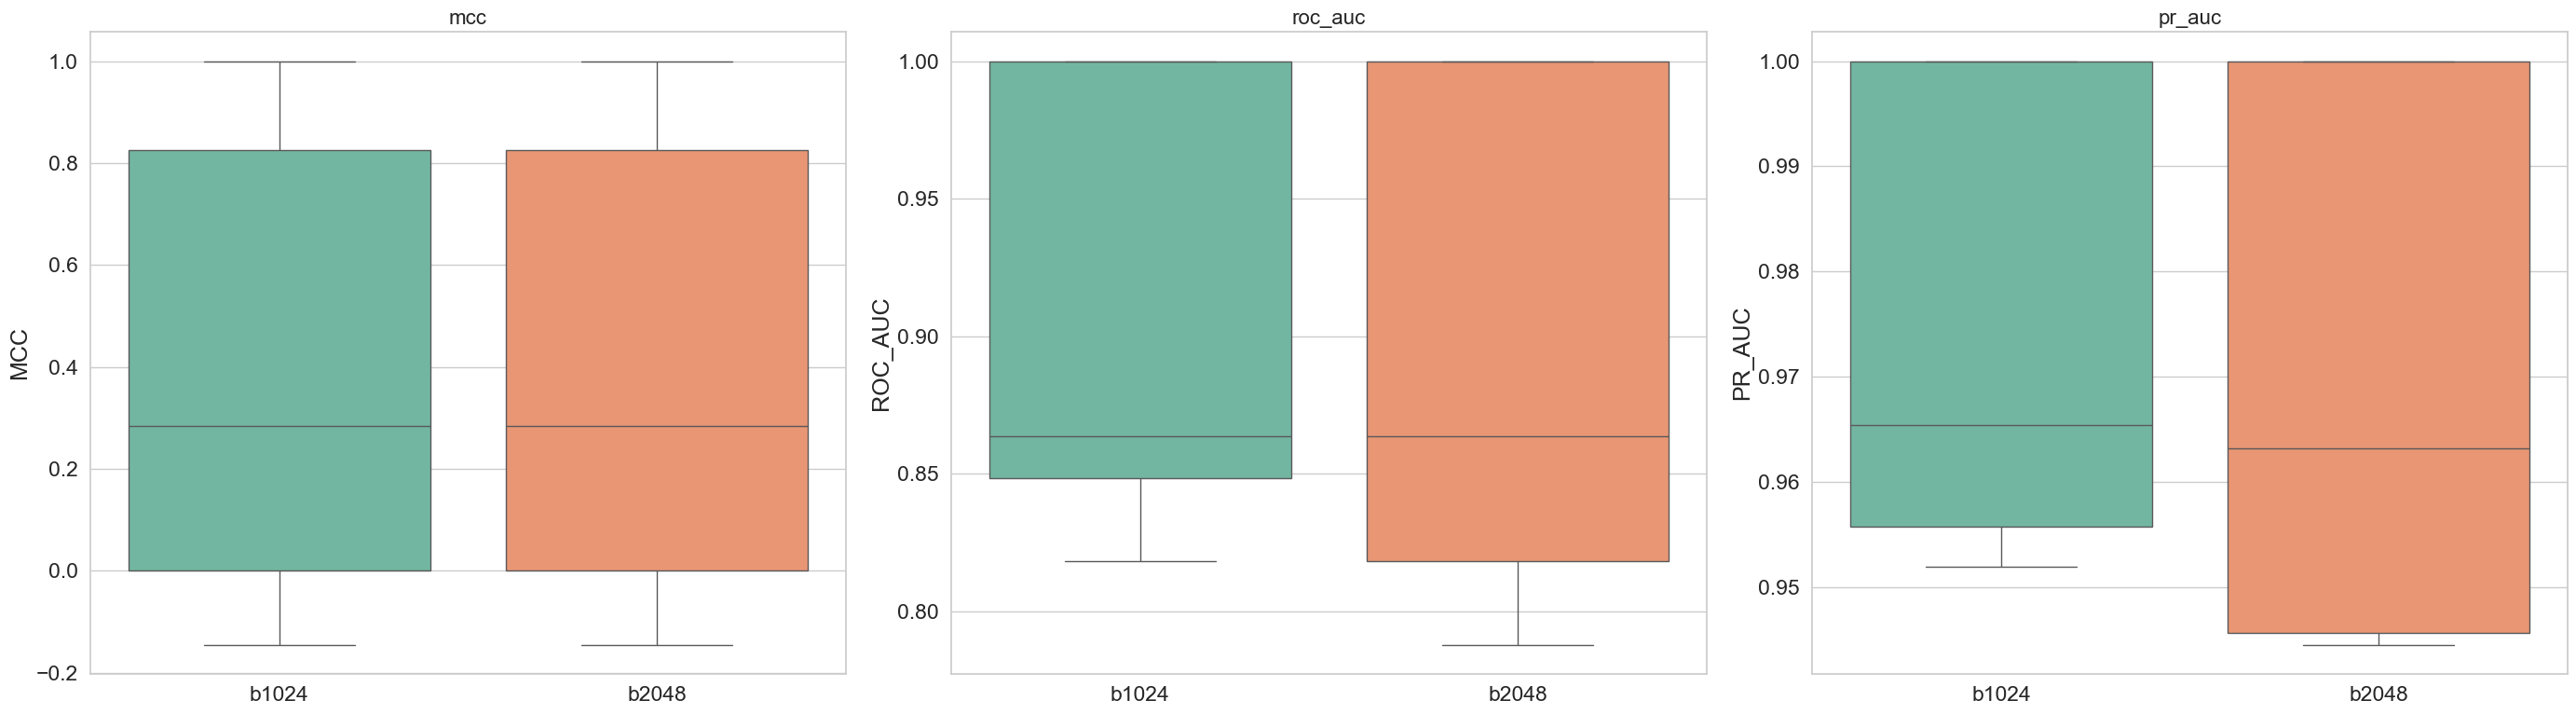

In [8]:
# %%  ▶ Aggregate + rename so that AnovaRM sees exactly one (cv_cycle × method) per row
import matplotlib.pyplot as plt
import model_comparison

# Use the correct metric columns and grouping columns from `data`
metric_ls  = ['mcc', 'roc_auc', 'pr_auc']
cols       = metric_ls  # use the lowercase metric names as in `data`

# 1) average duplicates (if any)
agg = (
    data
    .groupby(['cv_cycle', 'method'])[cols]
    .mean()
    .reset_index()
)

print("Aggregated DataFrame columns:", agg.columns.tolist())
print("Rows per cv_cycle×method:")
print(agg.groupby(['cv_cycle','method']).size())

# 2) call your boxplot function
model_comparison.make_boxplots_parametric(agg, cols)

# 3) grab the current figure & axes and set titles
fig = plt.gcf()
axes = fig.axes  # list of Axes in the order they were drawn
for ax, title in zip(axes, cols):
    ax.set_title(title, fontsize=16)

fig.tight_layout()


In [10]:
import importlib
import model_comparison
importlib.reload(model_comparison)



<module 'model_comparison' from 'm:\\EPSRC Internship 2025\\Project\\Data\\Classification Model\\Comparisons\\Polaris\\model_comparison.py'>

# 10. Perform Post-Hoc Analysis to Examine Differences Between Methods (MCS Plots)

c:\Users\hllpacke\.conda\envs\epimerisation\lib\site-packages\pingouin\parametric.py:571: RuntimeWarning: invalid value encountered in scalar divide
  fval = ms_with / ms_reswith
m:\EPSRC Internship 2025\Project\Data\Classification Model\Comparisons\Polaris\model_comparison.py:114: RuntimeWarning: invalid value encountered in scalar divide
  studentized_range = np.abs(mean_diff) / tukey_se
c:\Users\hllpacke\.conda\envs\epimerisation\lib\site-packages\scipy\optimize\_optimize.py:2360: OptimizeWarning: 
NaN result encountered.
  _endprint(x, flag, fval, maxfun, xatol, disp)


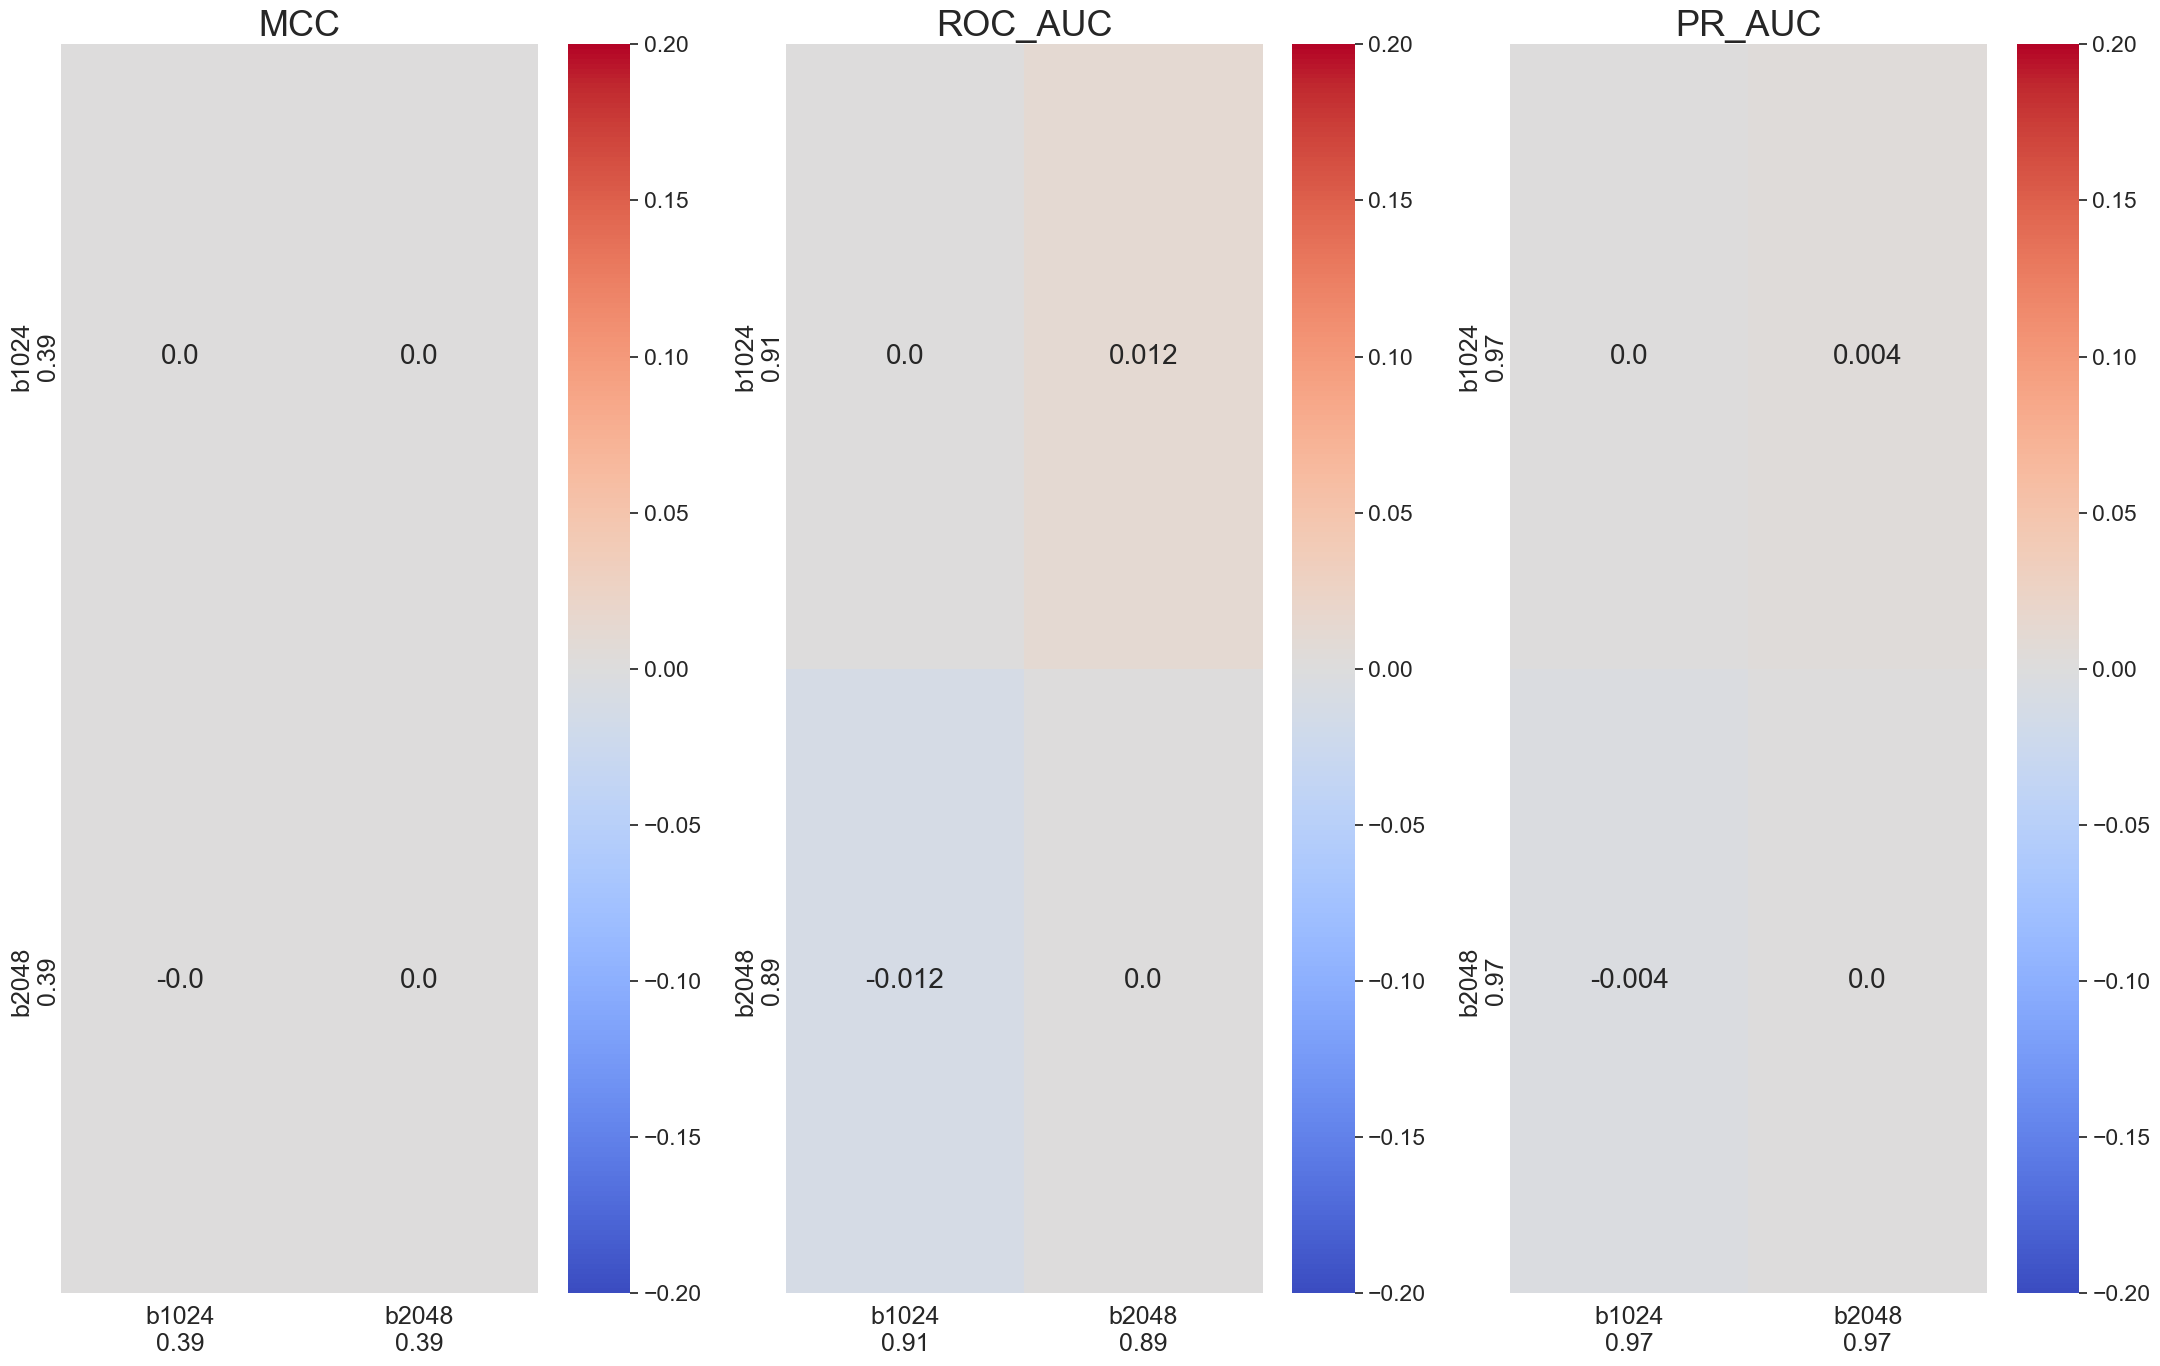

In [11]:
effect_dict = {'roc_auc':.1, 'pr_auc':.1, 'mcc':.1}
direction_dict = {'roc_auc':'maximize', 'pr_auc':'maximize', 'mcc':'maximize'}    
model_comparison.make_mcs_plot_grid(data, metric_ls, group_col="method", effect_dict=effect_dict, direction_dict=direction_dict,
                   figsize=(22, 14), cell_text_size=20, axis_text_size=18, title_text_size=26, show_diff=True, sort_axes=True)

# 11. Difference in Confidence Intervals

c:\Users\hllpacke\.conda\envs\epimerisation\lib\site-packages\pingouin\parametric.py:571: RuntimeWarning: invalid value encountered in scalar divide
  fval = ms_with / ms_reswith
m:\EPSRC Internship 2025\Project\Data\Classification Model\Comparisons\Polaris\model_comparison.py:114: RuntimeWarning: invalid value encountered in scalar divide
  studentized_range = np.abs(mean_diff) / tukey_se
c:\Users\hllpacke\.conda\envs\epimerisation\lib\site-packages\scipy\optimize\_optimize.py:2360: OptimizeWarning: 
NaN result encountered.
  _endprint(x, flag, fval, maxfun, xatol, disp)


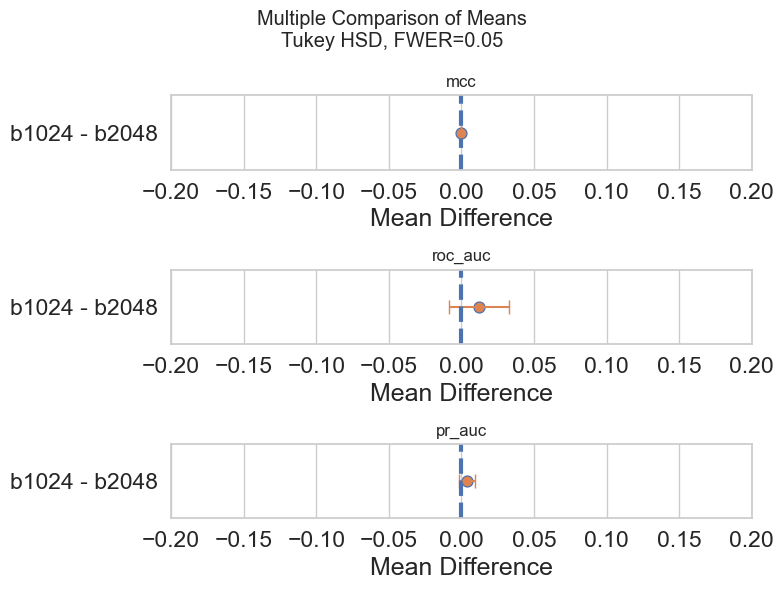

In [12]:
make_ci_plot_grid(data, metric_ls, "method")

# 12. Violin Plots 

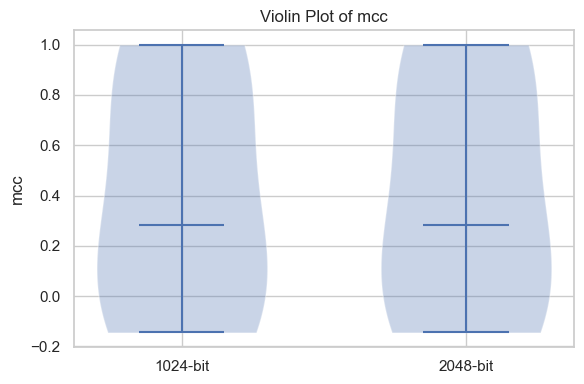

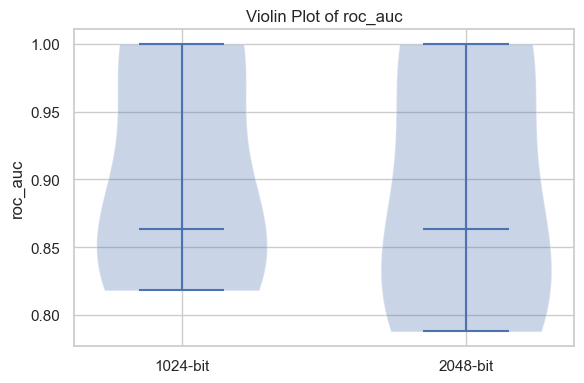

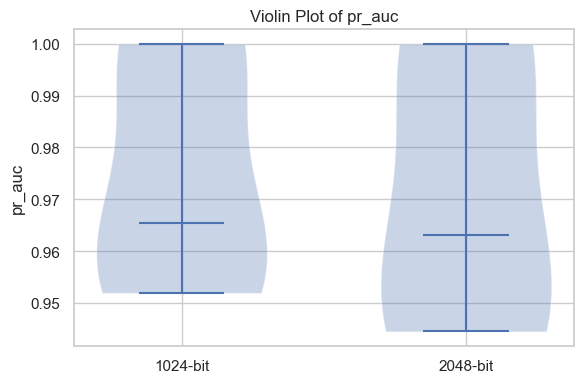

In [13]:
# ─── VIOLIN PLOTS FOR CROSS-VALIDATED METRICS ─────

# list of metrics to plot
metrics = ['mcc', 'roc_auc', 'pr_auc']

for metric in metrics:
    # split out 1024 vs 2048
    d1 = data.loc[data.method == 'b1024', metric].values
    d2 = data.loc[data.method == 'b2048', metric].values

    # ----- Simple Violin -----
    fig, ax = plt.subplots(figsize=(6,4))
    ax.violinplot([d1, d2],
                  positions=[1,2],
                  widths=0.6,
                  showmedians=True)
    ax.set_xticks([1,2])
    ax.set_xticklabels(['1024-bit', '2048-bit'])
    ax.set_ylabel(metric)
    ax.set_title(f"Violin Plot of {metric}")
    plt.tight_layout()
    plt.show()

 
